In [19]:

import numpy as np
from dataclasses import dataclass
import pandas as pd
from pathlib import Path
import json

ROOT = Path.cwd().absolute().parent
LINEARIZED_MODEL_NPZ = ROOT / "data" / "linearized_operational_space_xyz.npz"
MICRO_MASS_DIAG_KG = 0.0

@dataclass
class MacroOscillatorParams:
    M: np.ndarray  # (2,2) total mass matrix (macro + micro)
    C: np.ndarray  # (2,2) damping matrix
    K: np.ndarray  # (2,2) stiffness matrix

    def __post_init__(self):
        for name, arr in [("M", self.M), ("K", self.K), ("C", self.C)]:
            if arr.shape != (2, 2):
                raise ValueError(f"{name} must have shape (2,2), got {arr.shape}")
            

def load_macro_from_npz(npz_path, axes=(0, 1)):
    npz_path = Path(npz_path)
    if not npz_path.exists():
        raise FileNotFoundError(f"Linearized model not found: {npz_path}")
    data = np.load(npz_path, allow_pickle=False)
    Lambda = data["Lambda_xyz"]  # (3,3)
    Dx     = data["Dx_xyz"]      # (3,3)
    Kx     = data["Kx_xyz"]      # (3,3)

    a0, a1 = axes
    M2 = Lambda[np.ix_([a0, a1], [a0, a1])]
    C2 = Dx[np.ix_([a0, a1], [a0, a1])]
    K2 = Kx[np.ix_([a0, a1], [a0, a1])]
    extras = {k: data[k] for k in data.files if k not in ["Lambda_xyz", "Dx_xyz", "Kx_xyz"]}
    return M2, C2, K2, extras


M2, C2, K2, _ = load_macro_from_npz(LINEARIZED_MODEL_NPZ, axes=(0, 1))
M_micro = np.eye(2) * MICRO_MASS_DIAG_KG
Mtot = M2 + M_micro
p_osc = MacroOscillatorParams(M=Mtot, C=C2, K=K2)

In [28]:
GRADIENT_BATCH_ID = (
    "20260307_123434__origin_20260306_211831__left_20260306_221950__right_20260306_232207"
)

GRADIENT_DIR = ROOT / "data" / "experiments" / "gradients" / GRADIENT_BATCH_ID
GRADIENT_XY_CSV = GRADIENT_DIR / "gradients_xy.csv"
GRADIENT_S_CSV = GRADIENT_DIR / "gradients_s.csv"
GRADIENT_METADATA_JSON = GRADIENT_DIR / "mini-metadata" / "metadata.json"


# Load gradient data
grad_xy_df = pd.read_csv(GRADIENT_XY_CSV)
grad_s_df = pd.read_csv(GRADIENT_S_CSV)

# Load metadata
with open(GRADIENT_METADATA_JSON, encoding="utf-8") as f:
    grad_metadata = json.load(f)

print("Loaded gradient batch:", GRADIENT_BATCH_ID)

# Shape: (N, 2, 2)
K_proc = np.stack(
    [
        np.column_stack(
            [
                grad_xy_df["dFx_dx_N_per_mm"].to_numpy(),
                grad_xy_df["dFx_dy_N_per_mm"].to_numpy(),
            ]
        ),
        np.column_stack(
            [
                grad_xy_df["dFy_dx_N_per_mm"].to_numpy(),
                grad_xy_df["dFy_dy_N_per_mm"].to_numpy(),
            ]
        ),
    ],
    axis=1,
)

s_grad_mm = grad_xy_df["s_mm"].to_numpy()

K_eff = p_osc.K[None, :, :] - K_proc * 1e3

Minv = np.linalg.inv(p_osc.M)

A_t = np.empty((len(K_eff), 4, 4))
I2 = np.eye(2)
Z2 = np.zeros((2, 2))

for i in range(len(K_eff)):
    A_t[i] = np.block([
        [Z2,            I2],
        [-Minv @ K_eff[i], -Minv @ p_osc.C],
    ])

print("A_t shape:", A_t.shape)   # (N, 4, 4)

Loaded gradient batch: 20260307_123434__origin_20260306_211831__left_20260306_221950__right_20260306_232207
A_t shape: (308, 4, 4)


eigvals shape: (308, 4)
max alpha: -3.7714543099746263
min alpha: -3.859644293122212


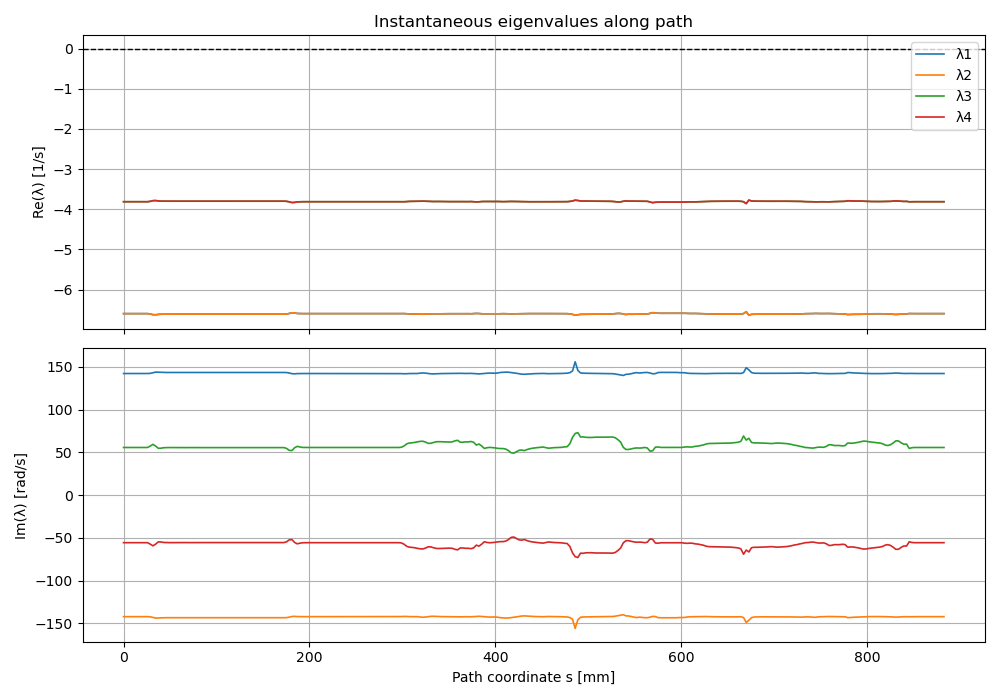

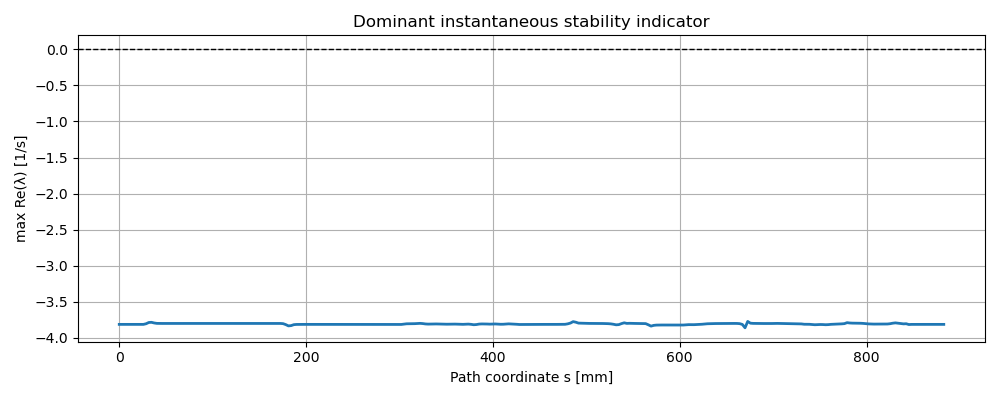

In [29]:
import matplotlib.pyplot as plt
%matplotlib widget


eigvals = np.linalg.eigvals(A_t)   # shape: (N, 4)

eig_real = eigvals.real
eig_imag = eigvals.imag
alpha = np.max(eig_real, axis=1)   # dominant real part

print("eigvals shape:", eigvals.shape)
print("max alpha:", alpha.max())
print("min alpha:", alpha.min())

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for j in range(eigvals.shape[1]):
    ax[0].plot(s_grad_mm, eig_real[:, j], linewidth=1.2, label=f"λ{j+1}")
ax[0].axhline(0.0, color="k", linestyle="--", linewidth=1.0)
ax[0].set_ylabel("Re(λ) [1/s]")
ax[0].set_title("Instantaneous eigenvalues along path")
ax[0].grid(True)
ax[0].legend()

for j in range(eigvals.shape[1]):
    ax[1].plot(s_grad_mm, eig_imag[:, j], linewidth=1.2, label=f"λ{j+1}")
ax[1].set_ylabel("Im(λ) [rad/s]")
ax[1].set_xlabel("Path coordinate s [mm]")
ax[1].grid(True)

fig.tight_layout()

plt.figure(figsize=(10, 4))
plt.plot(s_grad_mm, alpha, linewidth=2.0)
plt.axhline(0.0, color="k", linestyle="--", linewidth=1.0)
plt.xlabel("Path coordinate s [mm]")
plt.ylabel("max Re(λ) [1/s]")
plt.title("Dominant instantaneous stability indicator")
plt.grid(True)
plt.tight_layout()

Loaded feed profile: /home/irz/code/milling_sim_study/optimized_feed/optimization_offline_cc/Optimal_feed_curve.csv
Columns: ['x_support', 'feed_curve']
Origin feed-per-tooth: 0.7200000000000001


,x_support,feed_curve
0,0.000000,0.000000
1,6.138636,58.741607
2,12.277273,63.997457
3,18.415909,64.503690
4,24.554546,52.628437


Eigenvalue array shape: (308, 4)


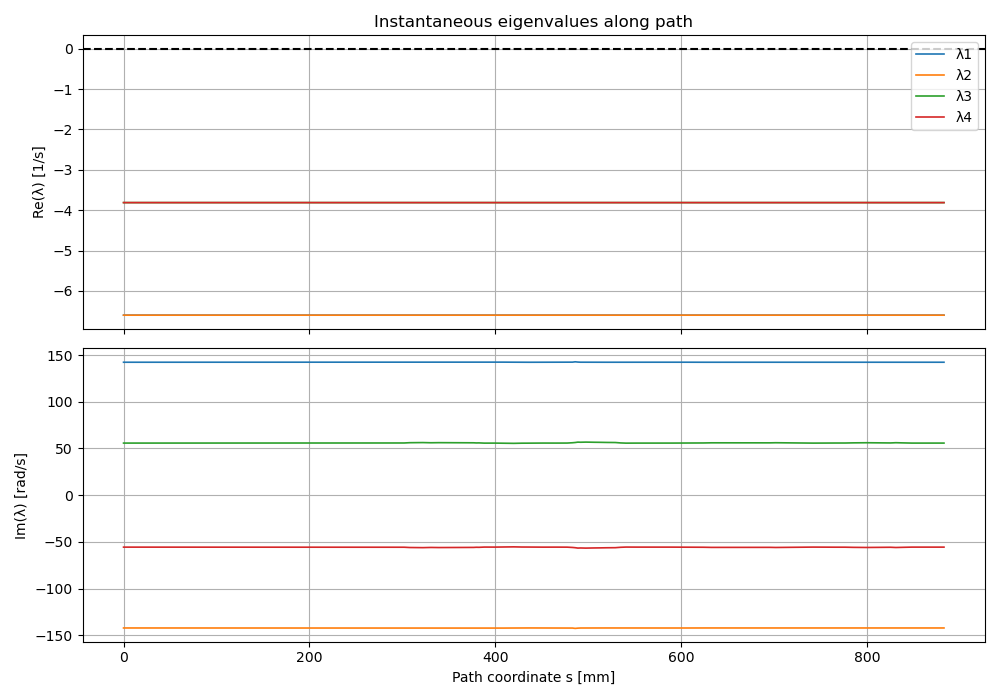

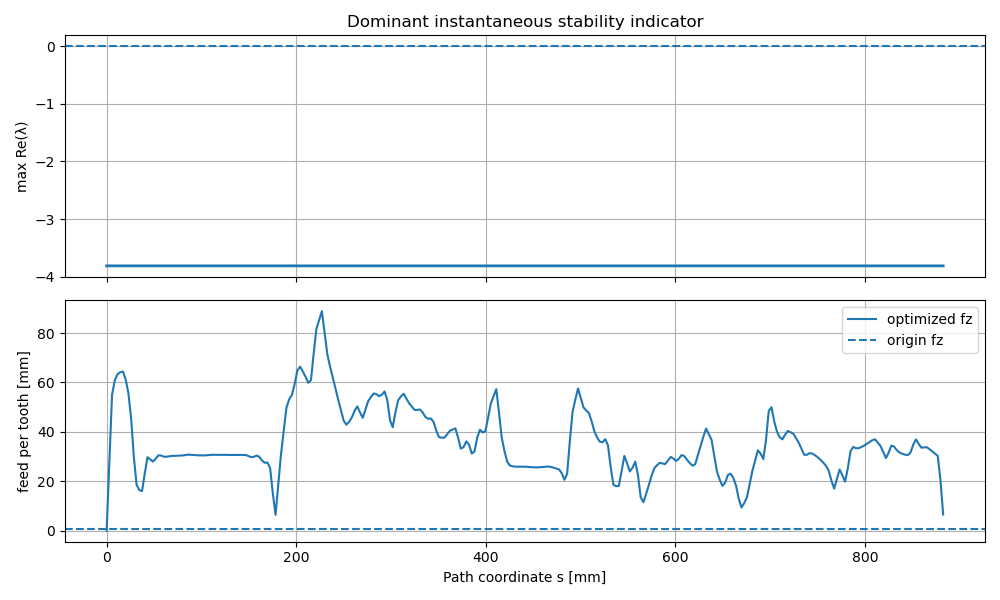

In [30]:
# --- Feed-scaled process stiffness and instantaneous eigenvalues ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Path to optimized feed profile
FEED_PROFILE_CSV = ROOT / "optimized_feed" / "optimization_offline_cc" / "Optimal_feed_curve.csv"

# Load feed profile
feed_profile = pd.read_csv(FEED_PROFILE_CSV)

print("Loaded feed profile:", FEED_PROFILE_CSV)
print("Columns:", feed_profile.columns.tolist())

# Compute origin feed-per-tooth (same logic used earlier)
def feed_per_tooth(params: dict) -> float:
    if "feed_per_tooth_mm" in params:
        return float(params["feed_per_tooth_mm"])

    if {"rpm", "feed_speed_mm_s", "z_teeth"}.issubset(params):
        rpm = float(params["rpm"])
        feed_mm_s = float(params["feed_speed_mm_s"])
        teeth = int(params["z_teeth"])
        rev_per_s = rpm / 60.0
        return feed_mm_s / (rev_per_s * teeth)

    rpm = float(params["spindle_speed_rpm"])
    feed_mm_per_min = float(params["feed_rate_mm_per_min"])
    tooth_count = int(params["tool_tooth_count"])
    return feed_mm_per_min / (rpm * tooth_count)


# Resolve origin parameters from gradient metadata
origin_params_path = Path(grad_metadata["runs"]["origin"]["params_json"])
with open(origin_params_path) as f:
    origin_params_dict = json.load(f)

origin_fz = feed_per_tooth(origin_params_dict)
print("Origin feed-per-tooth:", origin_fz)

# Interpolate optimized feed profile onto gradient path coordinate

display(feed_profile.head())
fz_new = np.interp(
    s_grad_mm,
    feed_profile["x_support"].to_numpy(),
    feed_profile["feed_curve"].to_numpy(),
)

# Normalize gradient by origin feed-per-tooth
K_proc_normalized = K_proc / origin_fz

# Apply optimized feed profile
K_proc_scaled = K_proc_normalized * fz_new[:, None, None]

# Compute effective stiffness
K_eff = p_osc.K[None, :, :] - K_proc_scaled

# Build time-varying state matrix
Minv = np.linalg.inv(p_osc.M)

N = len(K_eff)
A_t = np.empty((N, 4, 4))

I2 = np.eye(2)
Z2 = np.zeros((2, 2))

for i in range(N):
    A_t[i] = np.block([
        [Z2, I2],
        [-Minv @ K_eff[i], -Minv @ p_osc.C],
    ])

# Compute instantaneous eigenvalues
eigvals = np.linalg.eigvals(A_t)

eig_real = eigvals.real
eig_imag = eigvals.imag
alpha = np.max(eig_real, axis=1)

print("Eigenvalue array shape:", eigvals.shape)

# --- Plot eigenvalues ---

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for j in range(4):
    ax[0].plot(s_grad_mm, eig_real[:, j], linewidth=1.2, label=f"λ{j+1}")

ax[0].axhline(0.0, color="k", linestyle="--")
ax[0].set_ylabel("Re(λ) [1/s]")
ax[0].set_title("Instantaneous eigenvalues along path")
ax[0].grid(True)
ax[0].legend()

for j in range(4):
    ax[1].plot(s_grad_mm, eig_imag[:, j], linewidth=1.2)

ax[1].set_ylabel("Im(λ) [rad/s]")
ax[1].set_xlabel("Path coordinate s [mm]")
ax[1].grid(True)

plt.tight_layout()


# --- Plot dominant stability indicator and feed profile ---

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(s_grad_mm, alpha, linewidth=2)
ax[0].axhline(0, linestyle="--")
ax[0].set_ylabel("max Re(λ)")
ax[0].set_title("Dominant instantaneous stability indicator")
ax[0].grid(True)

ax[1].plot(s_grad_mm, fz_new, label="optimized fz")
ax[1].axhline(origin_fz, linestyle="--", label="origin fz")
ax[1].set_ylabel("feed per tooth [mm]")
ax[1].set_xlabel("Path coordinate s [mm]")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
